<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/06-Deep-Learning/02-PyTorch-Computer-Vision/05_food101_transfer_learning_EfficientNetB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import torch
from torch import nn
from torch.utils.data import Dataset , DataLoader
import torchvision
from torchvision import transforms
from torchvision import datasets

import torchvision.models as models

In [38]:
train_transform=transforms.Compose([
                                   transforms.Resize((224,224)),
                                   transforms.RandomHorizontalFlip(p=0.5),
                                   transforms.RandomVerticalFlip(p=0.5),
                                   transforms.RandomRotation(degrees=30),
                                   transforms.ColorJitter(brightness=0.1,contrast=0.1,saturation=0.1,hue=0.1),
                                   transforms.ToTensor(),
                                   transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
                                   ])

test_transform=transforms.Compose([
                                   transforms.Resize((224,224)),
                                   transforms.ToTensor(),
                                   transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
                                   ])

train_dataset=torchvision.datasets.Food101(
                                           root='./data',
                                           split='train',
                                           download=True,
                                           transform=train_transform
                                           )
test_dataset=torchvision.datasets.Food101(
                                           root='./data',
                                           split='test',
                                           download=True,
                                           transform=test_transform
                                           )

In [39]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device='cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


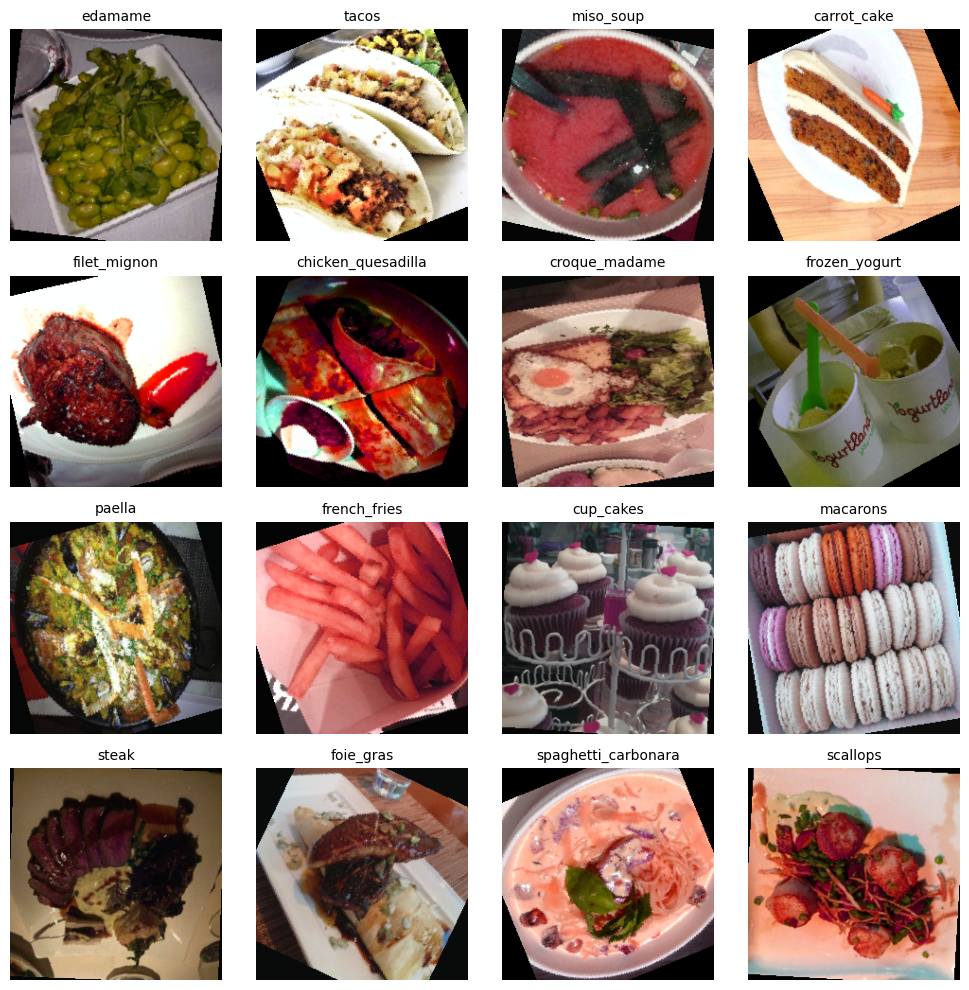

In [40]:
plt.figure(figsize=(10,10))
for i in range (16):
  idx=random.randint(0,len(train_dataset)-1)
  img,label=train_dataset[idx]
  class_name=train_dataset.classes[label]

  plt.subplot(4,4,i+1)

  img_np = img.permute(1, 2, 0).numpy()
  # same values of meas and std be used to normalize this dataset with
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])

  # Un-normalize (Math: X = X_norm * std + mean) (we are now un-normalize a the images we got from the dataset for better visualization)
  img_np = std * img_np + mean
  img_np = np.clip(img_np, 0, 1) # Force any weird floating point stragglers into [0, 1]

  plt.imshow(img_np)
  plt.title(class_name, fontsize=10)
  plt.axis('off')

plt.tight_layout()   #Adjusts spacing
plt.show()

In [42]:
BATCH_SIZE=64

train_datalodear=DataLoader(
                            dataset=train_dataset,
                            batch_size=BATCH_SIZE,
                            num_workers=2,
                            pin_memory=True,
                            shuffle=True
                            )
test_datalodear=DataLoader(
                           dataset=test_dataset,
                           batch_size=BATCH_SIZE,
                           num_workers=2,
                           pin_memory=True,
                           shuffle=False
                           )

train_datalodear,test_datalodear

(<torch.utils.data.dataloader.DataLoader at 0x7e44abf343e0>,
 <torch.utils.data.dataloader.DataLoader at 0x7e44fd06ee70>)

In [43]:
img_batch,label_batch=next(iter(train_datalodear))
img_batch.shape,label_batch.shape

(torch.Size([64, 3, 224, 224]), torch.Size([64]))

In [44]:
efficientnet_model=models.efficientnet_b3(weights='DEFAULT',).to('cuda')

In [45]:
for params in efficientnet_model.features.parameters():
  params.requires_grad=False

In [46]:
efficientnet_model.classifier=nn.Sequential(
                                     nn.Dropout(p=0.2,inplace=False),

                                     nn.Linear(in_features=1536,out_features=256),
                                     nn.ReLU(),
                                     nn.Dropout(p=0.3,inplace=False),

                                     nn.Linear(in_features=256,out_features=128),
                                     nn.ReLU(),
                                     nn.Dropout(p=0.3,inplace=False),

                                     nn.Linear(in_features=128,out_features=101)
                                    ).to(device)

In [47]:
for param in efficientnet_model.features[7].parameters():
    param.requires_grad = True

for param in efficientnet_model.features[8].parameters():
    param.requires_grad = True

In [48]:
!pip -q install torchmetrics
import torchmetrics as tm
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=efficientnet_model.parameters(),lr=0.001)

accuracy=tm.Accuracy(task='multiclass',num_classes=101).to(device)
recall=tm.Recall(task='multiclass',num_classes=101).to(device)
precision=tm.Precision(task='multiclass',num_classes=101).to(device)

In [50]:
from tqdm.auto import tqdm
from timeit import default_timer as timer

strat_time=timer()

epochs=10
plt_epochs=[]
plt_train_loss=[]
plt_train_accuracy=[]
plt_train_recall=[]
plt_train_precision=[]

for ecophs in tqdm(range(epochs)):
  efficientnet_model.train()
  train_loss=0

  for batch,(X,y) in enumerate(train_datalodear):
    X,y=X.to(device),y.to(device)

    y_pred=efficientnet_model(X)

    loss=loss_fn(y_pred,y)
    train_loss+=loss.item()

    accuracy.update(y_pred, y)
    precision.update(y_pred, y)
    recall.update(y_pred, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  plt_epochs.append(ecophs)
  train_loss /= len(train_datalodear)

  # Compute the final metrics ONCE at the end of the epoch
  epoch_accuracy = accuracy.compute().item()
  epoch_precision = precision.compute().item()
  epoch_recall = recall.compute().item()

  accuracy.reset()
  precision.reset()
  recall.reset()

  #appending the avg train_loss etc to there respected list for ploting
  plt_train_loss.append(train_loss)
  plt_train_accuracy.append(epoch_accuracy)
  plt_train_recall.append(epoch_recall)
  plt_train_precision.append(epoch_precision)

  torch.save(efficientnet_model.state_dict(), f'efficientnet_epoch_{ecophs+1}.pth')
  print(f"\n--------------- Epoch: {ecophs+1} | train_loss: {train_loss:.4f} | train_accuracy: {epoch_accuracy:.4f} | train_recall: {epoch_recall:.4f} | train_precision: {epoch_precision:.4f} ---------------\n")

end_time=timer()
total_time=end_time-strat_time
print(f"Total Training Time: {total_time:.3f} seconds")


  0%|          | 0/10 [00:00<?, ?it/s]


--------------- Epoch: 1 | train_loss: 2.7936 | train_accuracy: 0.2973 | train_recall: 0.2973 | train_precision: 0.2973 ---------------


--------------- Epoch: 2 | train_loss: 2.2808 | train_accuracy: 0.4360 | train_recall: 0.4360 | train_precision: 0.4360 ---------------


--------------- Epoch: 3 | train_loss: 2.0916 | train_accuracy: 0.4826 | train_recall: 0.4826 | train_precision: 0.4826 ---------------


--------------- Epoch: 4 | train_loss: 1.9657 | train_accuracy: 0.5102 | train_recall: 0.5102 | train_precision: 0.5102 ---------------


--------------- Epoch: 5 | train_loss: 1.8864 | train_accuracy: 0.5297 | train_recall: 0.5297 | train_precision: 0.5297 ---------------


--------------- Epoch: 6 | train_loss: 1.8302 | train_accuracy: 0.5450 | train_recall: 0.5450 | train_precision: 0.5450 ---------------


--------------- Epoch: 7 | train_loss: 1.7756 | train_accuracy: 0.5563 | train_recall: 0.5563 | train_precision: 0.5563 ---------------


--------------- Epoch: 8 | train_

In [54]:
test_loss = 0.0
test_acc = 0.0

efficientnet_model.eval()
with torch.inference_mode():
    for X_test, y_test in test_datalodear:
        X_test, y_test = X_test.to(device), y_test.to(device)

        test_pred = efficientnet_model(X_test)

        loss = loss_fn(test_pred, y_test).item()
        test_loss += loss

        accuracy.update(test_pred, y_test)
        precision.update(test_pred, y_test)
        recall.update(test_pred, y_test)

    test_acc = accuracy.compute().item()
    test_loss = test_loss/len(test_datalodear)
    test_precision = precision.compute().item()
    test_recall = recall.compute().item()

    accuracy.reset()
    precision.reset()
    recall.reset()

print(f"\nFinal Test Loss: {test_loss:.4f} | Final Test Acc: {test_acc * 100:.2f}%")


Final Test Loss: 1.0705 | Final Test Acc: 70.98%


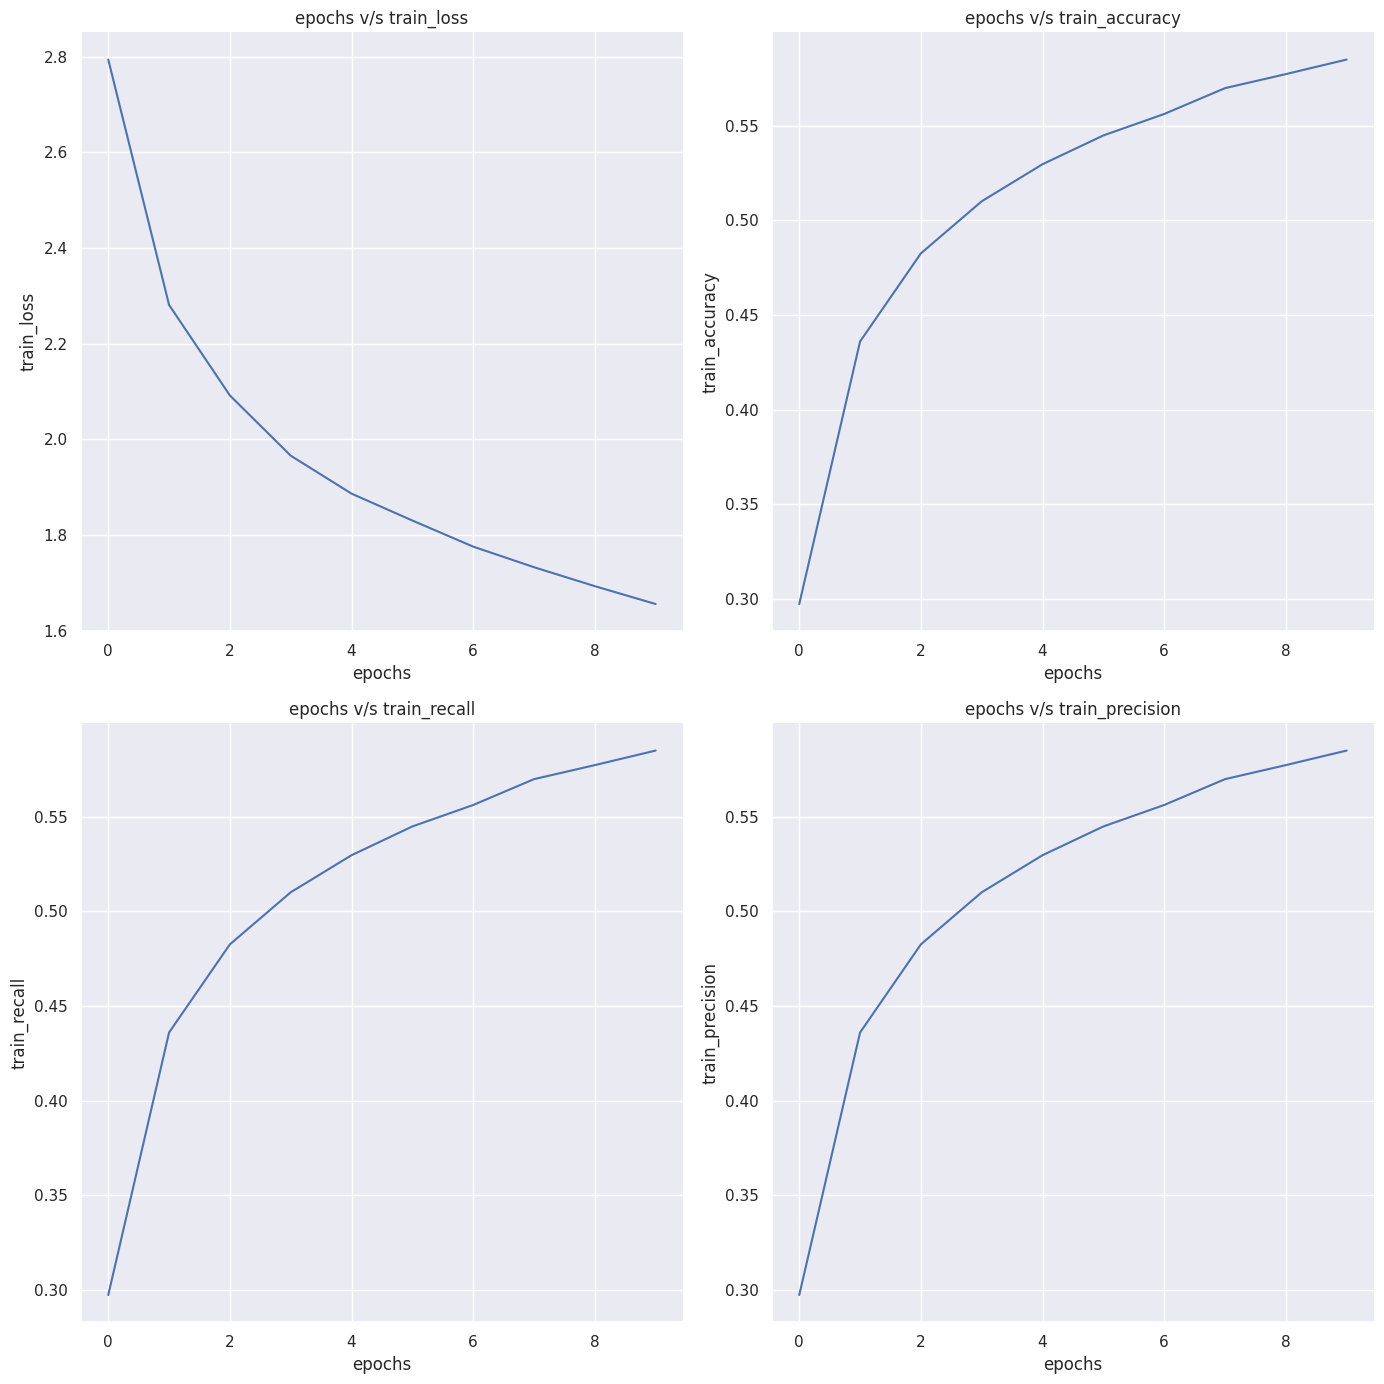

In [73]:
plt.figure(figsize=(14,14))
sns.set_theme(style='darkgrid')
plt.subplot(2,2,1)
plt.title("epochs v/s train_loss")
sns.lineplot(x=plt_epochs,y=plt_train_loss)
plt.xlabel('epochs')
plt.ylabel('train_loss')

plt.subplot(2,2,2)
plt.title("epochs v/s train_accuracy")
sns.lineplot(x=plt_epochs,y=plt_train_accuracy)
plt.xlabel('epochs')
plt.ylabel('train_accuracy')

plt.subplot(2,2,3)
plt.title("epochs v/s train_recall")
sns.lineplot(x=plt_epochs,y=plt_train_recall)
plt.xlabel('epochs')
plt.ylabel('train_recall')

plt.subplot(2,2,4)
plt.title("epochs v/s train_precision")
sns.lineplot(x=plt_epochs,y=plt_train_precision)
plt.xlabel('epochs')
plt.ylabel('train_precision')

plt.tight_layout()
sns.despine()
plt.show()

In [72]:
torch.save(efficientnet_model.state_dict(), f'final_efficientnet_epoch.pth')

In [74]:
import json

with open("food101_classes.json", "w") as f:
    json.dump(train_dataset.classes, f)

print("Export complete!")

Export complete!
